In [63]:
import os
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pretty_midi

from scipy.stats import entropy
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style="whitegrid")

CLASSICAL_DIR = "sampled_datasets/classical_midi"
POP_DIR = "sampled_datasets/pop_midi"
GAME_LOOPING_DIR = "sampled_datasets/game_looping_midi"
GAME_NOT_LOOPING_DIR = "sampled_datasets/game_not_looping_midi"

GENRE_FOLDERS = [
    ("classical", CLASSICAL_DIR),
    ("pop", POP_DIR),
    ("game_looping", GAME_LOOPING_DIR),
    ("game_not_looping", GAME_NOT_LOOPING_DIR),
]

GENRE_ORDER = [genre for genre, _ in GENRE_FOLDERS]

In [64]:
import os
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pretty_midi

from scipy.stats import entropy
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style="whitegrid")

CLASSICAL_DIR = "sampled_datasets/classical_midi"
POP_DIR = "sampled_datasets/pop_midi"
GAME_LOOPING_DIR = "sampled_datasets/game_looping_midi"
GAME_NOT_LOOPING_DIR = "sampled_datasets/game_not_looping_midi"

GENRE_FOLDERS = [
    ("classical", CLASSICAL_DIR),
    ("pop", POP_DIR),
    ("game_looping", GAME_LOOPING_DIR),
    ("game_not_looping", GAME_NOT_LOOPING_DIR),
]

GENRE_ORDER = [genre for genre, _ in GENRE_FOLDERS]

In [65]:
def rhythmic_entropy(pm):

    durations = []

    for instrument in pm.instruments:
        for note in instrument.notes:

            dur = round(note.end - note.start, 2)

            durations.append(dur)

    if len(durations) == 0:
        return np.nan

    counts = Counter(durations)

    probs = (
        np.array(list(counts.values()))
        / len(durations)
    )

    return entropy(probs)

In [66]:
def rhythmic_repetition(pm, n=4):

    durations = []

    for instrument in pm.instruments:
        for note in instrument.notes:

            dur = round(note.end - note.start, 2)

            durations.append(dur)

    if len(durations) < n:
        return np.nan

    ngrams = [
        tuple(durations[i:i+n])
        for i in range(len(durations)-n)
    ]

    counts = Counter(ngrams)

    repeated = sum(
        c for c in counts.values()
        if c > 1
    )

    return repeated / len(ngrams)

In [67]:
def pitch_entropy(pm):

    pitches = []

    for instrument in pm.instruments:
        for note in instrument.notes:

            pitches.append(
                note.pitch % 12
            )

    if len(pitches) == 0:
        return np.nan

    counts = Counter(pitches)

    probs = (
        np.array(list(counts.values()))
        / len(pitches)
    )

    return entropy(probs)

In [68]:
def chord_diversity(pm, window_beats=4, grid=0.25):

    windows = make_windows(
        pm,
        window_beats=window_beats,
        grid=grid
    )

    if len(windows) == 0:
        return np.nan

    chords = [
        tuple(window["chord"])
        for window in windows
        if len(window["chord"]) > 0
    ]

    if len(chords) == 0:
        return np.nan

    unique_chords = len(set(chords))

    return unique_chords / len(chords)


In [69]:
def quantize_notes(pm, grid=0.25):

    events = []

    for instrument in pm.instruments:

        for note in instrument.notes:

            start = round(note.start / grid) * grid
            end = round(note.end / grid) * grid

            dur = max(
                round((end - start) / grid),
                1
            )

            events.append({
                "start": int(round(start / grid)),
                "duration": int(dur),
                "pitch_class": note.pitch % 12,
            })

    return pd.DataFrame(events)


def beats_per_bar(pm):

    if len(pm.time_signature_changes) == 0:
        return 4

    counts = Counter(
        ts.numerator
        for ts in pm.time_signature_changes
    )

    return counts.most_common(1)[0][0]


def onset_count_profile(pm, grid=0.25):

    notes = quantize_notes(pm, grid=grid)

    meter = beats_per_bar(pm)

    if len(notes) == 0:
        return meter, {beat: 0 for beat in range(1, meter + 1)}

    ticks_per_beat = int(1 / grid)

    onset_counts = {beat: 0 for beat in range(1, meter + 1)}

    for start_tick in notes["start"]:
        beat_index = (start_tick // ticks_per_beat) % meter
        onset_counts[int(beat_index) + 1] += 1

    return meter, onset_counts



In [70]:
def make_windows(pm, window_beats=4, grid=0.25):

    notes = quantize_notes(pm, grid=grid)

    if len(notes) == 0:
        return []

    ticks_per_beat = int(1 / grid)

    window_size = (
        window_beats * ticks_per_beat
    )

    max_tick = notes["start"].max()

    windows = []

    for start in range(
        0,
        max_tick + 1,
        window_size
    ):

        sub = notes[
            (notes["start"] >= start)
            &
            (notes["start"] < start + window_size)
        ]

        if len(sub) == 0:
            continue

        rhythm = tuple(sorted([
            (
                int(row.start - start),
                int(row.duration)
            )
            for row in sub.itertuples()
        ]))

        pitches = tuple(sorted(
            sub["pitch_class"].tolist()
        ))

        chord = tuple(sorted(set(
            sub["pitch_class"].tolist()
        )))

        windows.append({
            "window_start": start,
            "rhythm": rhythm,
            "pitches": pitches,
            "chord": chord,
        })

    return windows

In [71]:
def recurrence_structure_details(pm):

    motifs = make_windows(pm)

    if len(motifs) == 0:
        return []

    rhythm_groups = defaultdict(list)

    for i, motif in enumerate(motifs):

        rhythm_groups[
            motif["rhythm"]
        ].append(i)

    repeated = {
        r: idxs
        for r, idxs in rhythm_groups.items()
        if len(idxs) > 1
    }

    recurrence_data = []

    for rhythm, idxs in repeated.items():

        idxs = sorted(idxs)

        occurrences = []

        for idx in idxs:

            motif = motifs[idx]

            occurrences.append({
                "window_start":
                    motif["window_start"],
                "chord":
                    motif["chord"],
                "pitches":
                    motif["pitches"]
            })

        recurrence_data.append({
            "rhythm": rhythm,
            "count": len(idxs),
            "occurrences": occurrences
        })

    recurrence_data = sorted(
        recurrence_data,
        key=lambda x: x["count"],
        reverse=True
    )

    return recurrence_data

In [72]:
def recurrence_summary(pm):

    recurrence_data = recurrence_structure_details(pm)

    if len(recurrence_data) == 0:

        return {
            "motif_rate": 0,
            "avg_recurrence_span": 0,
            "same_rhythm_diff_chord_rate": 0
        }

    motifs = make_windows(pm)

    motif_rate = (
        len(recurrence_data)
        / len(motifs)
    )

    spans = []
    chord_changes = []

    for motif_data in recurrence_data:

        starts = [
            occ["window_start"]
            for occ in motif_data["occurrences"]
        ]

        span = (
            max(starts) - min(starts)
        ) / len(motifs)

        spans.append(span)

        chords = [
            set(occ["chord"])
            for occ in motif_data["occurrences"]
        ]

        for a, b in zip(chords[:-1], chords[1:]):

            union = len(a | b)

            if union == 0:
                continue

            distance = 1 - (
                len(a & b) / union
            )

            chord_changes.append(distance)

    return {
        "motif_rate":
            motif_rate,

        "avg_recurrence_span":
            np.mean(spans),

        "same_rhythm_diff_chord_rate":
            np.mean(chord_changes)
            if chord_changes else 0
    }

In [73]:
def extract_chord_sequence(pm):

    chroma = pm.get_chroma()

    if chroma.shape[1] == 0:
        return []

    sequence = []

    for t in range(chroma.shape[1]):

        active = tuple(
            np.where(chroma[:, t] > 0)[0]
        )

        sequence.append(active)

    compressed = []

    prev = None

    for chord in sequence:

        if chord != prev:

            compressed.append(chord)

        prev = chord

    return compressed

In [74]:
def chord_transition_features(pm):

    chords = extract_chord_sequence(pm)

    if len(chords) < 2:

        return {
            "unique_transitions": np.nan,
            "transition_entropy": np.nan,
            "top_transition_strength": np.nan,
        }

    transitions = [
        (chords[i], chords[i+1])
        for i in range(len(chords)-1)
    ]

    counts = Counter(transitions)

    probs = (
        np.array(list(counts.values()))
        / len(transitions)
    )

    unique_transitions = (
        len(counts) / len(transitions)
    )

    transition_entropy = entropy(probs)

    top_transition_strength = (
        max(counts.values())
        / len(transitions)
    )

    return {
        "unique_transitions":
            unique_transitions,

        "transition_entropy":
            transition_entropy,

        "top_transition_strength":
            top_transition_strength,
    }

In [75]:
def rhythm_vector(motif):

    vec = np.zeros(64)

    for start, dur in motif["rhythm"]:

        if start < 64:
            vec[start] += dur

    return vec

In [76]:
def plot_self_similarity(pm):

    motifs = make_windows(pm)

    if len(motifs) < 2:
        return

    vectors = np.array([
        rhythm_vector(m)
        for m in motifs
    ])

    distances = squareform(
        pdist(vectors, metric="cosine")
    )

    similarity = 1 - distances

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        similarity,
        cmap="magma"
    )

    plt.title(
        "Rhythmic Self-Similarity Matrix"
    )

    plt.xlabel("Time Window")
    plt.ylabel("Time Window")

    plt.tight_layout()
    plt.show()

In [77]:
def plot_recurrence_timeline(pm, top_n=10):

    recurrence_data = recurrence_structure_details(pm)

    if len(recurrence_data) == 0:
        return

    top = recurrence_data[:top_n]

    plt.figure(figsize=(14, 6))

    for y, motif_data in enumerate(top):

        starts = [
            occ["window_start"]
            for occ in motif_data["occurrences"]
        ]

        plt.scatter(
            starts,
            [y] * len(starts),
            s=120
        )

        for s in starts:

            plt.plot(
                [s, s],
                [y - 0.2, y + 0.2]
            )

    plt.yticks(
        range(len(top)),
        [
            f"motif_{i+1}"
            for i in range(len(top))
        ]
    )

    plt.xlabel("Time Window")

    plt.ylabel("Recurring Motif")

    plt.title(
        "Recurring Rhythmic Motifs Across Time"
    )

    plt.tight_layout()
    plt.show()

In [78]:
def print_harmonic_reuse(pm, top_n=5):

    recurrence_data = recurrence_structure_details(pm)

    top = recurrence_data[:top_n]

    for i, motif_data in enumerate(top):

        print("\n")
        print("=" * 50)

        print(f"MOTIF {i+1}")
        print(f"occurrences: {motif_data['count']}")

        print("=" * 50)

        for occ in motif_data["occurrences"]:

            print(
                f"time={occ['window_start']:4d}"
                f" | chord={occ['chord']}"
            )

In [79]:
def process_folder(folder, genre):

    rows = []

    for file in os.listdir(folder):

        if not (
            file.endswith(".mid")
            or
            file.endswith(".midi")
        ):
            continue

        path = os.path.join(folder, file)

        try:

            pm = pretty_midi.PrettyMIDI(path)

            recurrence = recurrence_summary(pm)

            transition = chord_transition_features(pm)

            row = {

                "genre": genre,
                "file": file,

                "rhythmic_entropy":
                    rhythmic_entropy(pm),

                "rhythmic_repetition":
                    rhythmic_repetition(pm),

                "pitch_entropy":
                    pitch_entropy(pm),

                "chord_diversity":
                    chord_diversity(pm),

                "motif_rate":
                    recurrence["motif_rate"],

                "avg_recurrence_span":
                    recurrence["avg_recurrence_span"],

                "same_rhythm_diff_chord_rate":
                    recurrence[
                        "same_rhythm_diff_chord_rate"
                    ],

                "unique_transitions":
                    transition["unique_transitions"],

                "transition_entropy":
                    transition["transition_entropy"],

                "top_transition_strength":
                    transition["top_transition_strength"],
            }

            rows.append(row)

            print("processed:", file)

        except Exception as e:

            print("failed:", file, e)

    return rows

In [80]:
all_rows = []

for genre, folder in GENRE_FOLDERS:

    all_rows += process_folder(
        folder,
        genre
    )

df = pd.DataFrame(all_rows)

print(df.head())

processed: haydn_43_1.mid
processed: ty_august.mid
processed: muss_2.mid
processed: waldstein_1.mid
processed: schumm-1.mid
processed: chpn_op23.mid
processed: chpn-p19.mid
processed: chpn_op7_2.mid
processed: chpn-p18.mid
processed: mendel_op19_1.mid
processed: grieg_kobold.mid
processed: muss_3.mid
processed: haydn_43_2.mid
processed: muss_1.mid
processed: burg_sylphen.mid
processed: waldstein_2.mid
processed: burg_quelle.mid
processed: mendel_op19_3.mid
processed: schub_d960_4.mid
processed: chpn_op7_1.mid
processed: schum_abegg.mid
processed: gra_esp_4.mid
processed: islamei.mid
processed: mendel_op19_2.mid
processed: schumm-3.mid
processed: waldstein_3.mid
processed: haydn_8_4.mid
processed: haydn_43_3.mid
processed: muss_4.mid
processed: bach_847.mid
processed: scn68_10.mid
processed: ty_dezember.mid
processed: scn15_10.mid
processed: chpn-p23.mid
processed: chpn-p9.mid
processed: burg_perlen.mid
processed: scn16_8.mid
processed: chpn-p22.mid
processed: liz_rhap09.mid
processed: 

/Users/margo/miniconda3/envs/ada/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


processed: Mega Man_Nintendo Entertainment System_Mega Man 5_Crystal Man Stage.mid
processed: Sonic_Sega Genesis_Sonic the Hedgehog 2_Death Egg Zone.mid
processed: Super Mario_Wii_Super Mario Galaxy 2_Pipe Room.mid
processed: Pokemon_Game Boy Color_Pokemon Pinball_Red Field Theme.mid
processed: Kirby_Wii_Kirbys Epic Yarn_Blub-Blub Ocean.mid
processed: Final Fantasy_Super Nintendo Entertainment System_Final Fantasy IV_Battle 2.mid
processed: Other games_Arcade_Mamorukun Curse!_YO-KAI Disco (Hells Entrance World).mid
processed: Donkey Kong_Nintendo 64_Donkey Kong 64_Creepy Castle (Wind Tower).mid
processed: Super Mario_Game Boy_Wario Land Super Mario Land 3_Kitchen Island.mid
processed: Mario Kart_Wii_Mario Kart Wii_Daisy Circuit.mid
processed: Other games_Nintendo Entertainment System_Mike Tysons Punch-Out!!_Fight Theme.mid
processed: Pokemon_Nintendo DS_Pokemon Ranger Shadows of Almia_Vien Forest.mid
processed: Mario Kart_Super Nintendo Entertainment System_Super Mario Kart_Donut Plain

/Users/margo/miniconda3/envs/ada/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


processed: Pokemon_Game Boy Advance_Pokemon Ruby Version & Pokemon Sapphire Version_Battle! (BrendanMay).mid
processed: Super Mario_Nintendo 3DS_Super Mario 3D Land_World 2.mid
processed: The Legend of Zelda_Nintendo GameCube_The Legend of Zelda The Wind Waker_Inside the Pirate Ship.mid
processed: The Legend of Zelda_Nintendo DS_The Legend of Zelda Spirit Tracks_Mini Boss (Dungeon).mid
processed: Super Mario_SNES_Super Mario World_Forest of Illusion_0.mid
processed: Ace Attorney_Nintendo DS_Phoenix Wright Ace Attorney Trials and Tribulations_Detention Center Elegy of the Detained.mid
processed: Super Mario_Super Nintendo Entertainment System_Super Mario RPG Legend of the Seven Stars_Fight Against Monsters.mid
processed: Undertale_PC_Undertale_Room of Dog.mid
processed: Kirby_Wii_Kirbys Epic Yarn_Future City.mid
processed: Pokemon_Nintendo DS_Pokemon Black Version 2 & Pokemon White Version 2_Battle! (Gym Leader-Hoenn Version).mid
processed: Super Mario_Super Nintendo Entertainment Syste

/Users/margo/miniconda3/envs/ada/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


processed: Mega Man_Nintendo Entertainment System_Mega Man 6_Intro.mid
processed: Animal Crossing_Nintendo 3DS_Animal Crossing New Leaf_Hypno KK (Music Box).mid
processed: Final Fantasy_Super Nintendo Entertainment System_Final Fantasy V_Victory Fanfare.mid
processed: Mega Man_Super Nintendo Entertainment System_Mega Man X_Ending.mid
processed: Super Smash Bros_Multiplatform_Super Smash Bros for Nintendo 3DS and Wii U_Classic Final Results.mid
processed: Super Smash Bros_Nintendo Switch_Super Smash Bros Ultimate_Classic Mode Defeat.mid
processed: Animal Crossing_Nintendo GameCube_Animal Crossing_KK Jazz (Aircheck).mid
processed: Other games_Arcade_Splatterhouse_Ending.mid
processed: Other games_Nintendo Entertainment System_Shadowgate_Game Over.mid
processed: Pokemon Mystery Dungeon_Nintendo DS_Pokemon Mystery Dungeon Explorers of Time & Pokemon Mystery Dungeon Explorers of Darkness_Epilogue Theme.mid
processed: Mega Man_Nintendo Entertainment System_Mega Man 2_Ending.mid
processed: Po

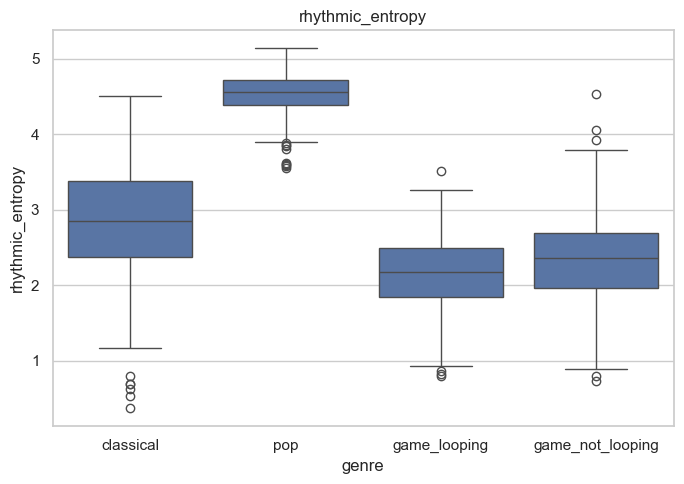

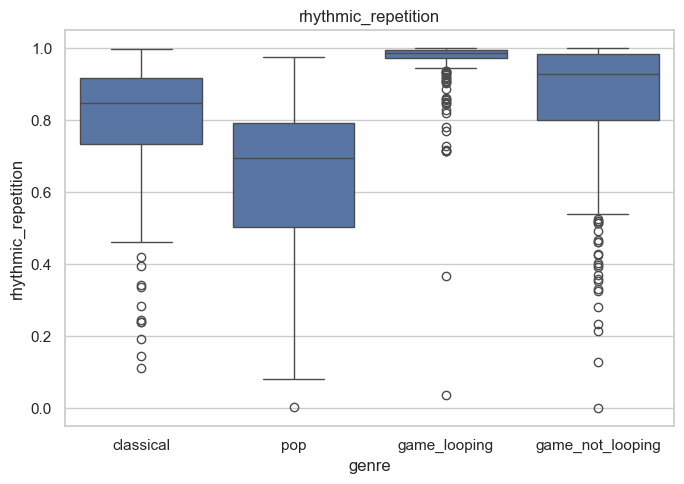

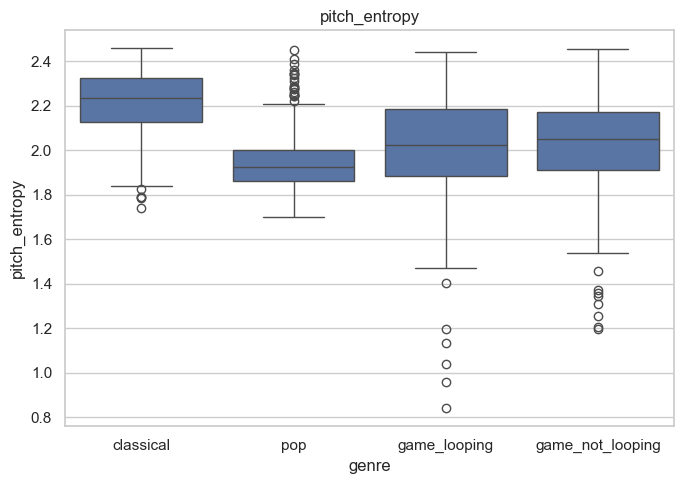

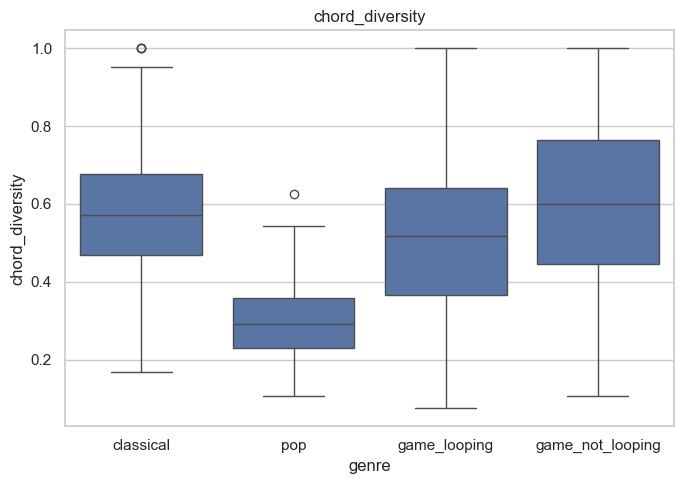

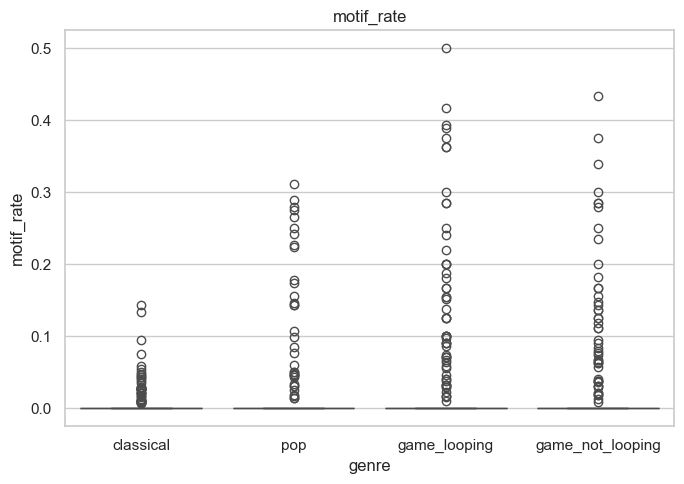

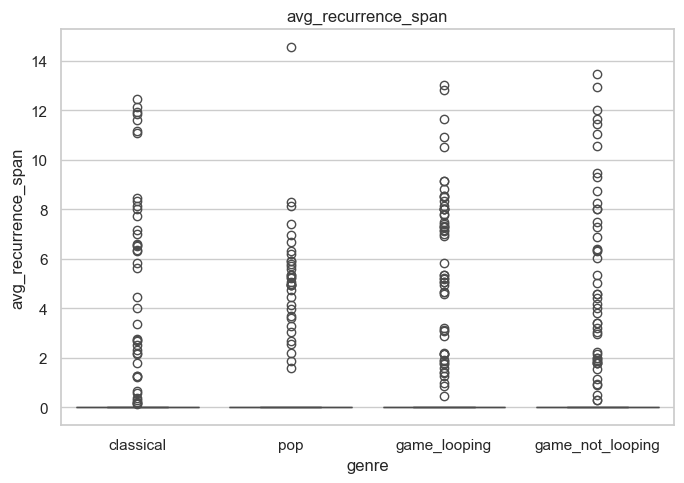

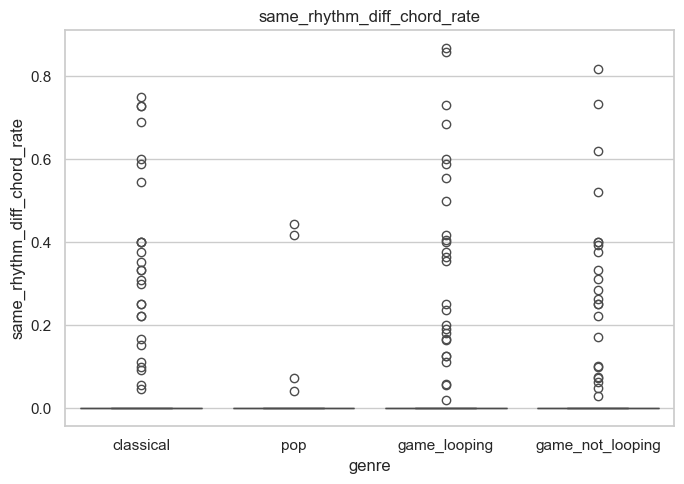

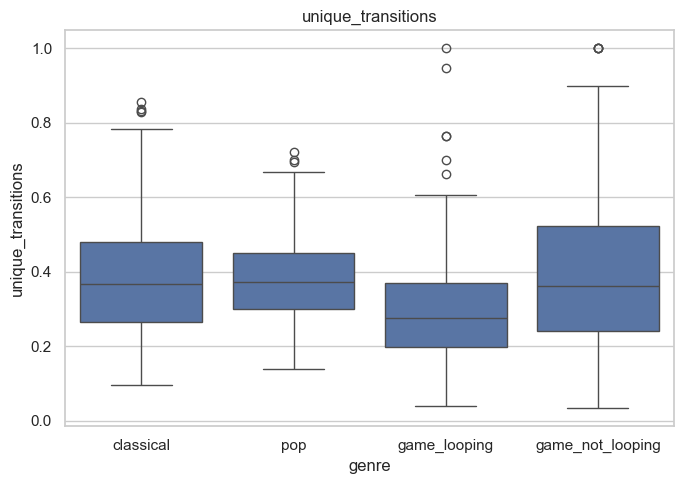

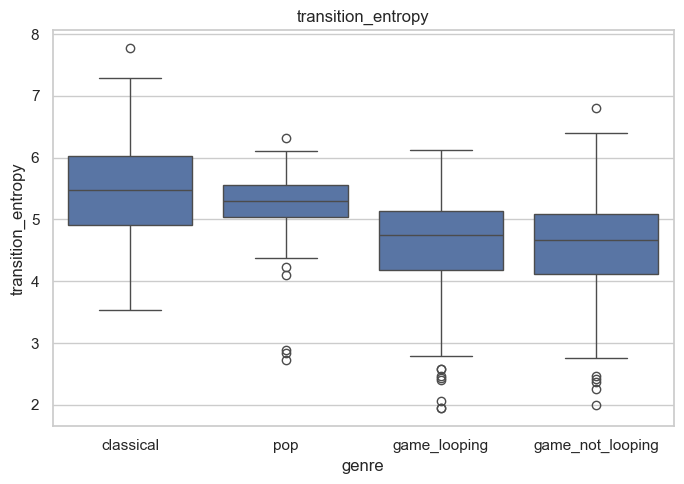

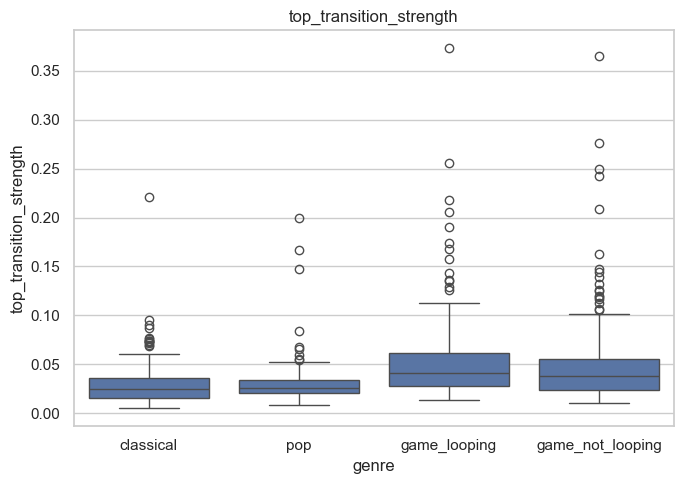

In [82]:
features = [

    "rhythmic_entropy",
    "rhythmic_repetition",
    "pitch_entropy",
    "chord_diversity",
    "motif_rate",
    "avg_recurrence_span",
    "same_rhythm_diff_chord_rate",
    "unique_transitions",
    "transition_entropy",
    "top_transition_strength",
]

for feature in features:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=df,
        x="genre",
        y=feature,
        order=GENRE_ORDER
    )

    plt.title(feature)

    plt.tight_layout()

    plt.show()

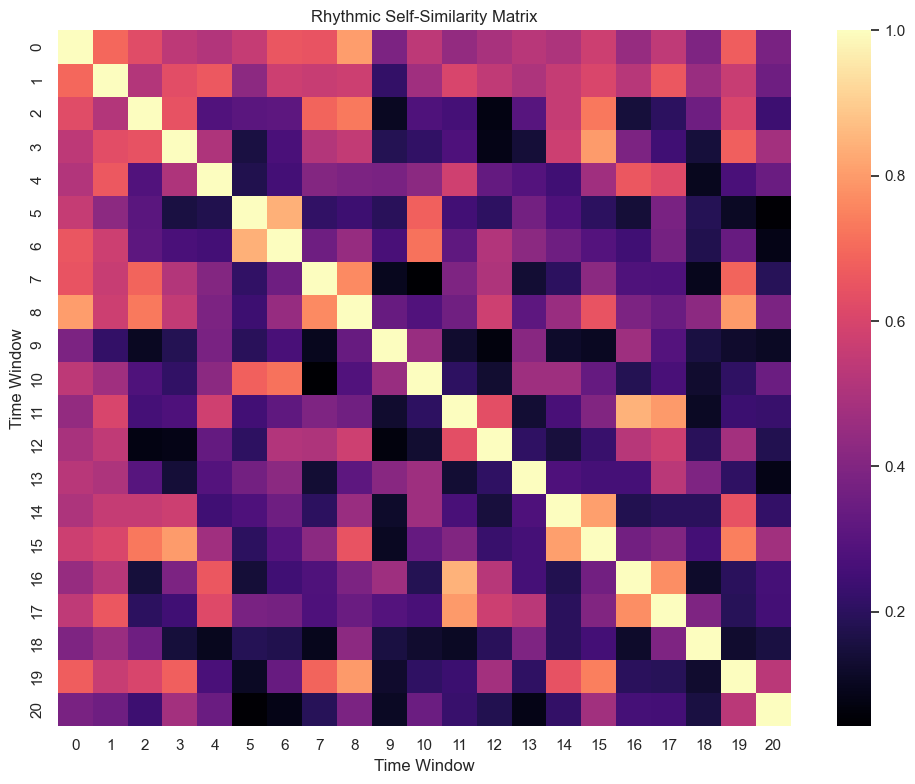

In [83]:
looping_example = df[df.genre == "game_looping"]["file"].iloc[0]

example_path = os.path.join(
    GAME_LOOPING_DIR,
    looping_example
)

pm = pretty_midi.PrettyMIDI(example_path)

plot_recurrence_timeline(pm)

plot_self_similarity(pm)

print_harmonic_reuse(pm)


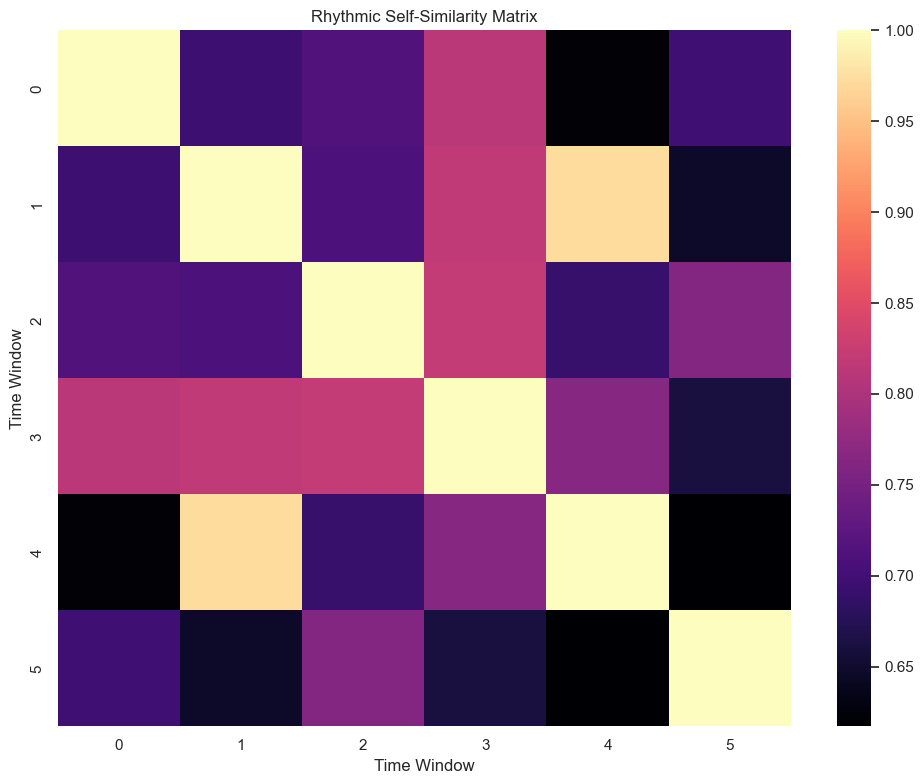

In [84]:
looping_example = df[df.genre == "game_not_looping"]["file"].iloc[0]

example_path = os.path.join(
    GAME_NOT_LOOPING_DIR,
    looping_example
)

pm = pretty_midi.PrettyMIDI(example_path)

plot_recurrence_timeline(pm)

plot_self_similarity(pm)

print_harmonic_reuse(pm)


/Users/margo/miniconda3/envs/ada/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(




classical vs game_looping

Strong-beat concentration:
          genre  strong_beat_percentage
0     classical               19.195818
1  game_looping               45.808158

Piece counts:
          genre  n_files
0     classical       80
1  game_looping      201


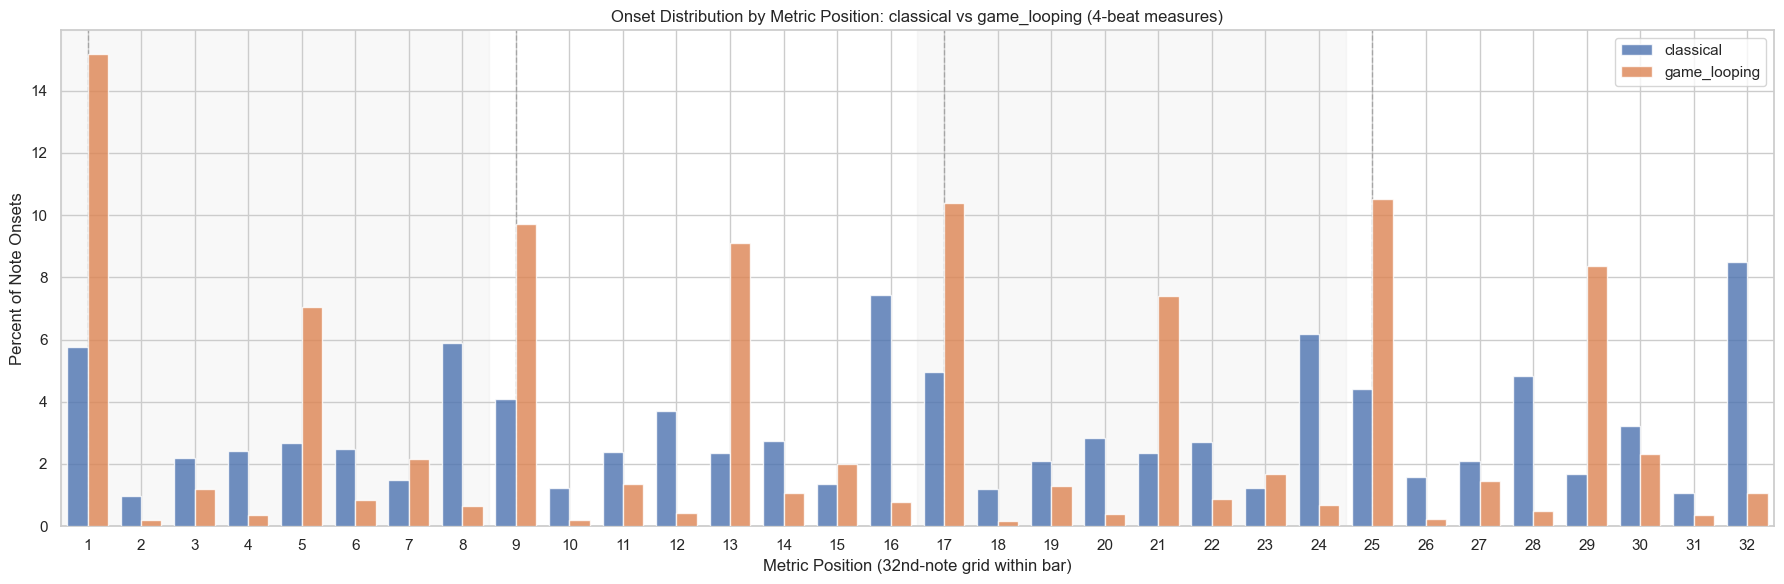



pop vs game_looping

Strong-beat concentration:
          genre  strong_beat_percentage
0  game_looping               45.808158
1           pop               12.071460

Piece counts:
          genre  n_files
0  game_looping      201
1           pop       83


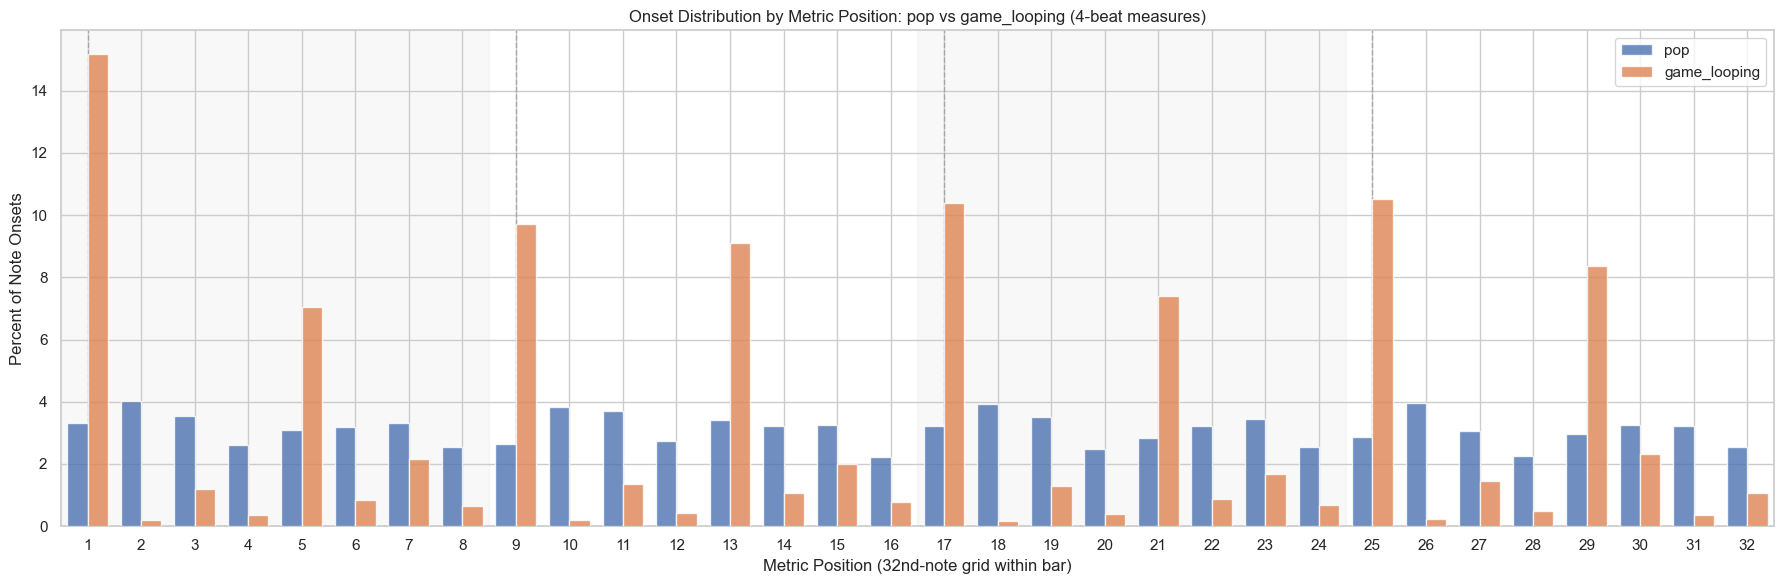



game_not_looping vs game_looping

Strong-beat concentration:
              genre  strong_beat_percentage
0      game_looping               45.808158
1  game_not_looping               47.751281

Piece counts:
              genre  n_files
0      game_looping      201
1  game_not_looping      183


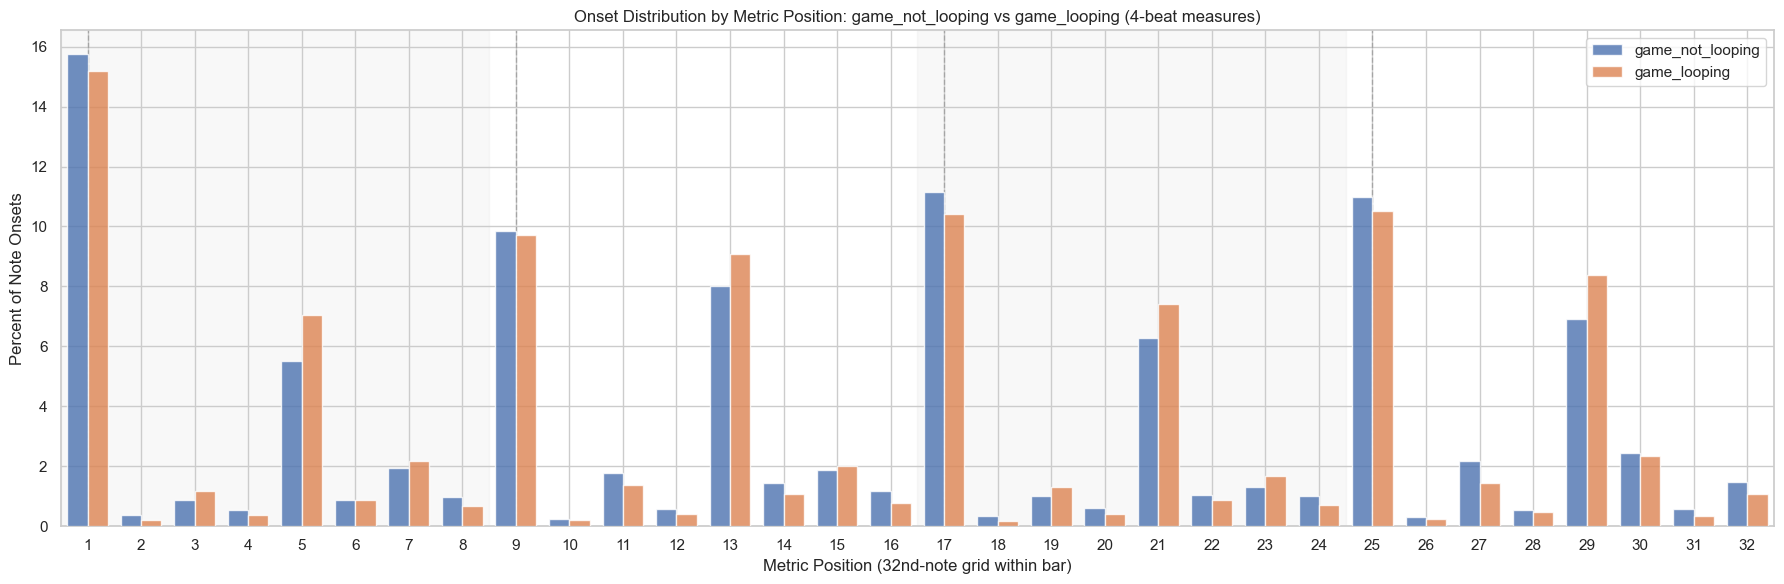


Other meters left over:
[np.int64(1), np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(11), np.int64(12), np.int64(20)]

Meter summaries:
              genre  total_files  \
0         classical          248   
1               pop          250   
2      game_looping          250   
3  game_not_looping          250   

                                     meter_breakdown  
0  {2: 47, 3: 70, 4: 80, 5: 6, 6: 35, 8: 2, 9: 5,...  
1                        {1: 160, 2: 5, 3: 2, 4: 83}  
2  {1: 3, 2: 9, 3: 12, 4: 201, 5: 2, 6: 9, 7: 1, ...  
3  {1: 4, 2: 7, 3: 31, 4: 183, 5: 1, 6: 14, 9: 2,...  

Leftover meter summary:
               genre  meter   count
5       game_looping      1    2676
13  game_not_looping      1    2359
20               pop      1  276224
0          classical      2  100918
6       game_looping      2    9184
14  game_not_looping      2    4849
21               pop      2    8061
1          classical      5   16545
7       game_looping      5    

In [106]:
from collections import Counter

import os
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt


SUBDIVISIONS = 8


def local_beats_per_bar(pm):

    if len(pm.time_signature_changes) == 0:
        return 4

    counts = Counter(
        ts.numerator
        for ts in pm.time_signature_changes
    )

    return counts.most_common(1)[0][0]


def local_metric_position_profile(
    pm,
    subdivisions=SUBDIVISIONS
):

    meter = local_beats_per_bar(pm)

    positions_per_bar = (
        meter * subdivisions
    )

    onset_counts = {
        pos: 0
        for pos in range(
            1,
            positions_per_bar + 1
        )
    }

    beats = pm.get_beats()

    if len(beats) < 2:

        return (
            meter,
            positions_per_bar,
            onset_counts
        )

    # -----------------------------------------
    # collect ALL notes individually
    # -----------------------------------------

    all_notes = []

    for instrument in pm.instruments:

        for note in instrument.notes:

            all_notes.append(note)

    if len(all_notes) == 0:

        return (
            meter,
            positions_per_bar,
            onset_counts
        )

    # -----------------------------------------
    # map note onsets to beat-relative bins
    # -----------------------------------------

    for note in all_notes:

        note_time = note.start

        beat_idx = (
            np.searchsorted(
                beats,
                note_time
            ) - 1
        )

        if beat_idx < 0:
            continue

        if beat_idx >= len(beats) - 1:
            continue

        beat_start = beats[beat_idx]

        beat_end = beats[
            beat_idx + 1
        ]

        beat_duration = (
            beat_end - beat_start
        )

        if beat_duration <= 0:
            continue

        relative_position = (
            note_time - beat_start
        ) / beat_duration

        subdivision = int(
            relative_position
            * subdivisions
        )

        if subdivision >= subdivisions:

            subdivision = (
                subdivisions - 1
            )

        metric_position = (
            (
                beat_idx % meter
            ) * subdivisions
        ) + subdivision + 1

        onset_counts[
            int(metric_position)
        ] += 1

    return (
        meter,
        positions_per_bar,
        onset_counts
    )


genre_position_rows = []
meter_summary_rows = []


for genre, folder in GENRE_FOLDERS:

    meter_counts = Counter()

    genre_total = 0

    for file in os.listdir(folder):

        if not (
            file.endswith(".mid")
            or
            file.endswith(".midi")
        ):
            continue

        path = os.path.join(
            folder,
            file
        )

        try:

            pm = pretty_midi.PrettyMIDI(
                path
            )

            (
                meter,
                positions_per_bar,
                piece_counts
            ) = local_metric_position_profile(
                pm,
                subdivisions=SUBDIVISIONS
            )

            meter_counts[meter] += 1

            genre_total += 1

            for (
                position,
                count
            ) in piece_counts.items():

                genre_position_rows.append({
                    "genre": genre,
                    "file": file,
                    "meter": meter,
                    "positions_per_bar": positions_per_bar,
                    "metric_position": int(position),
                    "count": count,
                })

        except Exception as e:

            print(
                "failed metric position profile:",
                file,
                e
            )

    meter_summary_rows.append({
        "genre": genre,
        "total_files": genre_total,
        "meter_breakdown": dict(
            sorted(
                meter_counts.items()
            )
        ),
    })


position_df = pd.DataFrame(
    genre_position_rows
)

meter_summary_df = pd.DataFrame(
    meter_summary_rows
)


comparison_pairs = [
    ("classical", "game_looping"),
    ("pop", "game_looping"),
    (
        "game_not_looping",
        "game_looping"
    ),
]


for target_meter in [4]:

    subset = position_df[
        position_df["meter"]
        == target_meter
    ].copy()

    if subset.empty:

        print(
            f"No pieces found in "
            f"{target_meter}-beat measures."
        )

        continue

    for (
        left_genre,
        right_genre
    ) in comparison_pairs:

        pair_subset = subset[
            subset["genre"].isin(
                [
                    left_genre,
                    right_genre
                ]
            )
        ].copy()

        if pair_subset.empty:
            continue

        available_genres = (
            pair_subset["genre"]
            .unique()
            .tolist()
        )

        if len(
            available_genres
        ) < 2:

            print(
                f"Skipping "
                f"{left_genre} vs "
                f"{right_genre}; "
                f"one side missing."
            )

            continue

        plot_df = (
            pair_subset
            .groupby(
                [
                    "genre",
                    "metric_position"
                ],
                as_index=False
            )["count"]
            .sum()
        )

        total_onsets_by_genre = (
            plot_df
            .groupby("genre")["count"]
            .transform("sum")
        )

        plot_df["percentage"] = (
            100
            * plot_df["count"]
            / total_onsets_by_genre
        )

        plot_df = (
            plot_df
            .sort_values(
                [
                    "metric_position",
                    "genre"
                ]
            )
        )

        plt.figure(
            figsize=(18, 6)
        )

        max_position = int(
            plot_df[
                "metric_position"
            ].max()
        )

        positions_per_beat = (
            SUBDIVISIONS
        )

        # alternating beat shading
        for block_start in range(
            1,
            max_position + 1,
            positions_per_beat
        ):

            block_end = min(
                block_start
                + positions_per_beat
                - 1,
                max_position
            )

            if (
                (
                    (
                        block_start - 1
                    )
                    // positions_per_beat
                ) % 2
            ) == 0:

                plt.axvspan(
                    block_start - 0.5,
                    block_end + 0.5,
                    color="lightgray",
                    alpha=0.15,
                    zorder=0
                )

        # beat-start lines
        for beat_start in range(
            1,
            max_position + 1,
            positions_per_beat
        ):

            plt.axvline(
                beat_start,
                color="gray",
                linestyle="--",
                linewidth=1,
                alpha=0.5,
                zorder=1
            )

        genres_in_plot = [
            left_genre,
            right_genre
        ]

        x = np.arange(
            1,
            max_position + 1
        )

        bar_width = 0.38

        for i, genre_name in enumerate(
            genres_in_plot
        ):

            genre_data = (
                plot_df[
                    plot_df["genre"]
                    == genre_name
                ]
                .sort_values(
                    "metric_position"
                )
            )

            offsets = (
                x - bar_width / 2
                if i == 0
                else x + bar_width / 2
            )

            plt.bar(
                offsets,
                genre_data[
                    "percentage"
                ],
                width=bar_width,
                alpha=0.8,
                label=genre_name,
                zorder=3
            )

        plt.title(
            f"Onset Distribution by "
            f"Metric Position: "
            f"{left_genre} vs "
            f"{right_genre} "
            f"(4-beat measures)"
        )

        plt.xlabel(
            "Metric Position "
            "(32nd-note grid within bar)"
        )

        plt.ylabel(
            "Percent of Note Onsets"
        )

        plt.xticks(x)

        plt.xlim(
            0.5,
            max_position + 0.5
        )

        strong_positions = [
            1 + i * SUBDIVISIONS
            for i in range(
                target_meter
            )
        ]

        strong_summary = (
            plot_df[
                plot_df[
                    "metric_position"
                ].isin(
                    strong_positions
                )
            ]
            .groupby("genre")[
                "percentage"
            ]
            .sum()
            .reset_index(
                name="strong_beat_percentage"
            )
        )

        print("\n")
        print(
            f"{left_genre} vs "
            f"{right_genre}"
        )

        print(
            "\nStrong-beat concentration:"
        )

        print(
            strong_summary
        )

        piece_counts = (
            pair_subset
            .groupby("genre")[
                "file"
            ]
            .nunique()
            .reset_index(
                name="n_files"
            )
        )

        print(
            "\nPiece counts:"
        )

        print(
            piece_counts
        )

        plt.legend()

        plt.tight_layout()

        plt.savefig(
            f"metric_position_histogram_"
            f"{left_genre}_vs_"
            f"{right_genre}_"
            f"{target_meter}_beat_measures.png",
            dpi=300
        )

        plt.show()


leftover_meters = sorted(
    meter
    for meter in (
        position_df["meter"]
        .dropna()
        .unique()
    )
    if meter not in {
        3,
        4,
        8
    }
)

print(
    "\nOther meters left over:"
)

print(leftover_meters)

print(
    "\nMeter summaries:"
)

print(
    meter_summary_df[
        [
            "genre",
            "total_files",
            "meter_breakdown"
        ]
    ]
)

if leftover_meters:

    leftover_summary = (
        position_df[
            position_df["meter"]
            .isin(
                leftover_meters
            )
        ]
        .groupby(
            [
                "genre",
                "meter"
            ],
            as_index=False
        )["count"]
            .sum()
            .sort_values(
                [
                    "meter",
                    "genre"
                ]
            )
    )

    print(
        "\nLeftover meter summary:"
    )

    print(
        leftover_summary
    )

/Users/margo/miniconda3/envs/ada/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


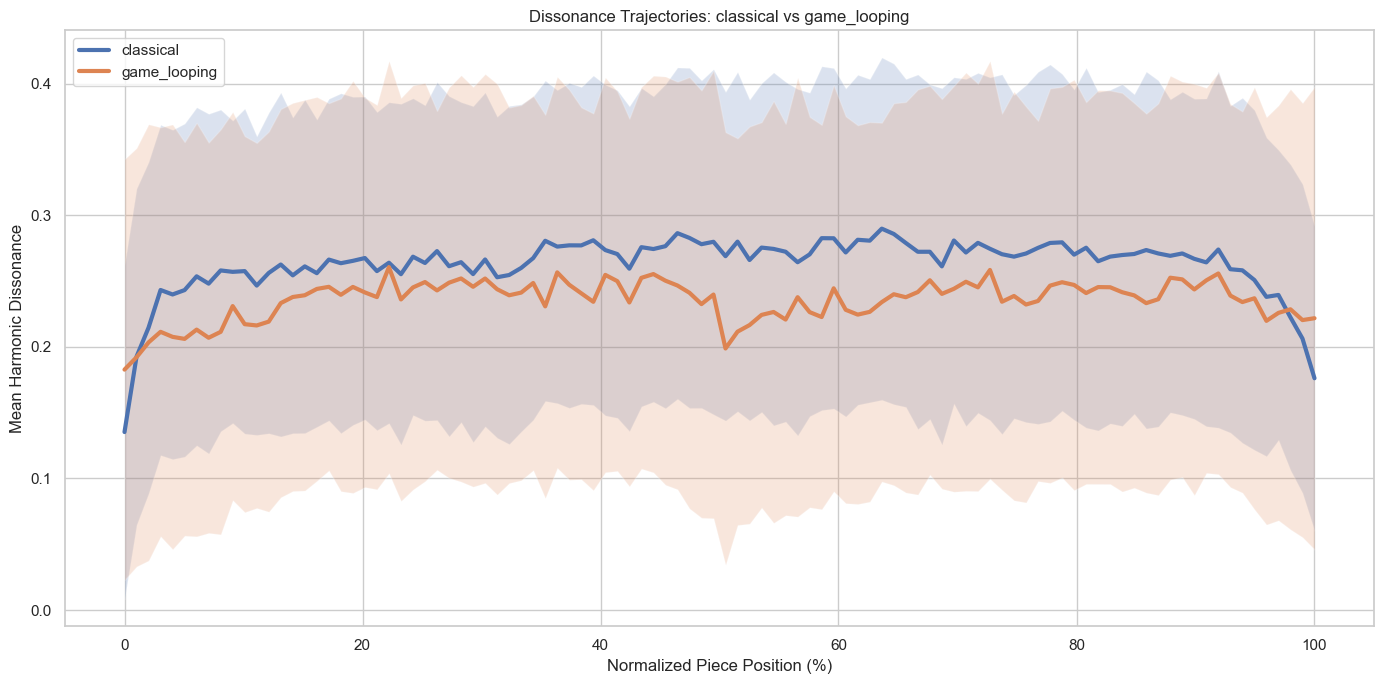

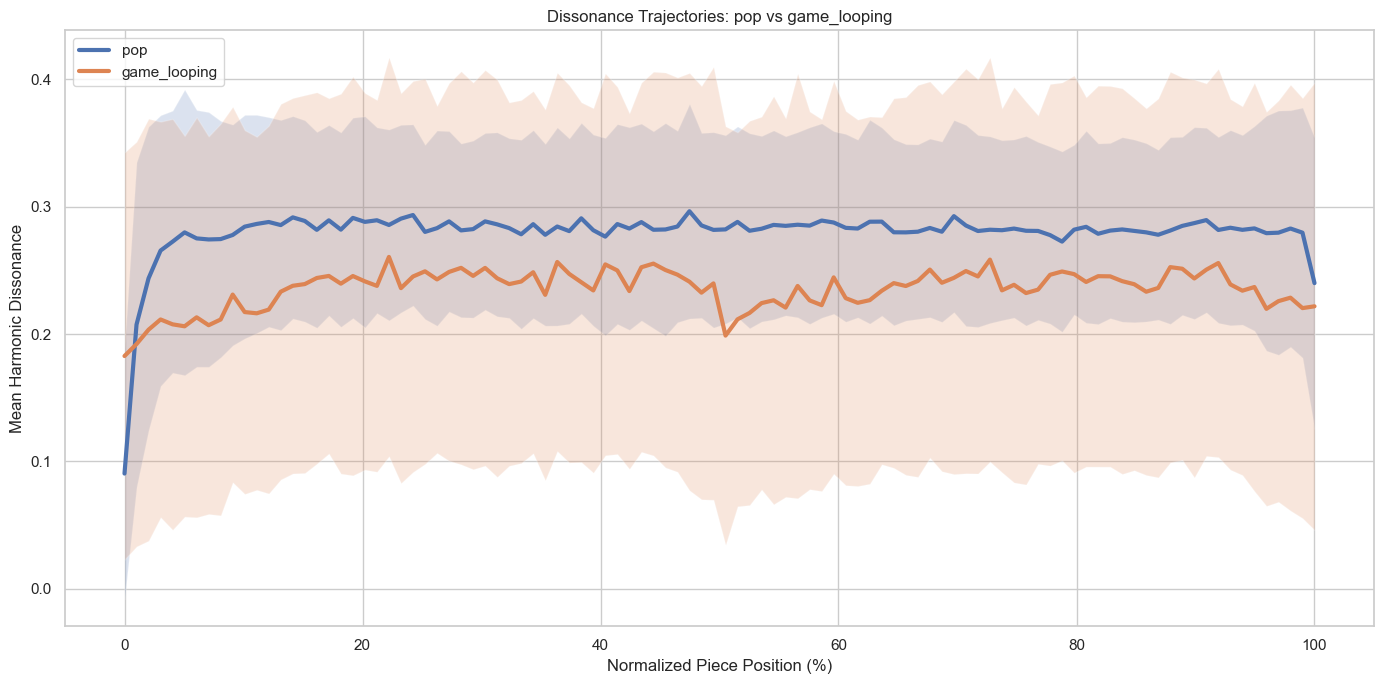

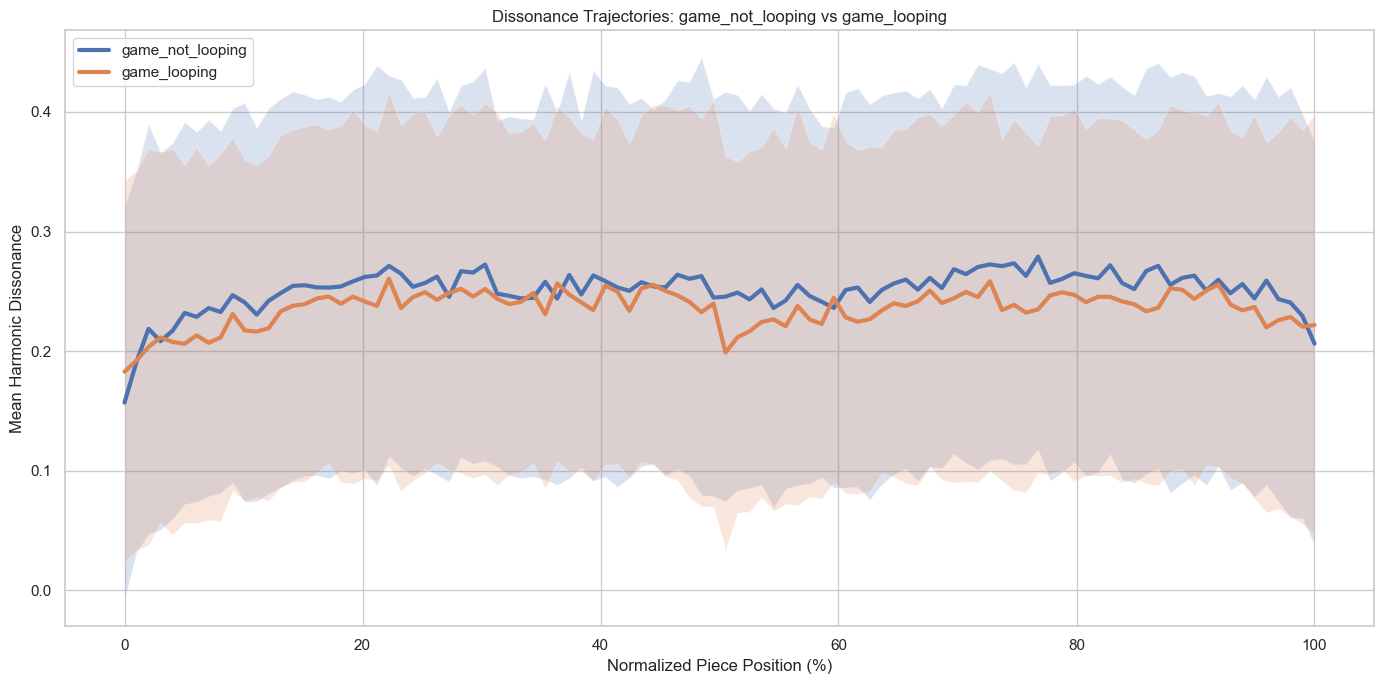

In [109]:
from collections import defaultdict
from itertools import combinations

import os
import numpy as np
import pandas as pd
import pretty_midi
import matplotlib.pyplot as plt


NUM_BINS = 100


INTERVAL_DISSONANCE = {
    0: 0.0,
    1: 1.0,
    2: 0.7,
    3: 0.3,
    4: 0.3,
    5: 0.2,
    6: 0.9,
    7: 0.05,
    8: 0.3,
    9: 0.3,
    10: 0.7,
    11: 1.0,
}


comparison_pairs = [
    ("classical", "game_looping"),
    ("pop", "game_looping"),
    ("game_not_looping", "game_looping"),
]


def chord_dissonance(pitches):

    pcs = sorted(
        list(set(
            p % 12
            for p in pitches
        ))
    )

    if len(pcs) < 2:
        return 0.0

    vals = []

    for a, b in combinations(pcs, 2):

        interval = abs(a - b) % 12

        vals.append(
            INTERVAL_DISSONANCE.get(
                interval,
                0.0
            )
        )

    if len(vals) == 0:
        return 0.0

    return np.mean(vals)


def piece_dissonance_curve(
    pm,
    num_bins=NUM_BINS,
    fs=10
):

    piano_roll = pm.get_piano_roll(fs=fs)

    total_frames = piano_roll.shape[1]

    if total_frames == 0:
        return np.zeros(num_bins)

    active_pitch_lists = []

    for t in range(total_frames):

        active = np.where(
            piano_roll[:, t] > 0
        )[0]

        active_pitch_lists.append(active)

    frame_scores = []

    for active in active_pitch_lists:

        score = chord_dissonance(active)

        frame_scores.append(score)

    frame_scores = np.array(frame_scores)

    bins = np.linspace(
        0,
        total_frames,
        num_bins + 1,
        dtype=int
    )

    curve = []

    for i in range(num_bins):

        start = bins[i]
        end = bins[i + 1]

        if end <= start:

            curve.append(0.0)

            continue

        curve.append(
            np.mean(
                frame_scores[start:end]
            )
        )

    return np.array(curve)


# ---------------------------------------------------------
# compute curves once
# ---------------------------------------------------------

genre_curves = defaultdict(list)

for genre, folder in GENRE_FOLDERS:

    for file in os.listdir(folder):

        if not (
            file.endswith(".mid")
            or file.endswith(".midi")
        ):
            continue

        path = os.path.join(
            folder,
            file
        )

        try:

            pm = pretty_midi.PrettyMIDI(path)

            curve = piece_dissonance_curve(pm)

            genre_curves[genre].append(curve)

        except Exception as e:

            print(
                "failed dissonance:",
                file,
                e
            )


# ---------------------------------------------------------
# pairwise plots
# ---------------------------------------------------------

x = np.linspace(
    0,
    100,
    NUM_BINS
)

for left_genre, right_genre in comparison_pairs:

    plt.figure(figsize=(14, 7))

    for genre in [
        left_genre,
        right_genre
    ]:

        curves = genre_curves[genre]

        if len(curves) == 0:
            continue

        mean_curve = np.mean(
            curves,
            axis=0
        )

        std_curve = np.std(
            curves,
            axis=0
        )

        plt.plot(
            x,
            mean_curve,
            linewidth=3,
            label=genre
        )

        plt.fill_between(
            x,
            mean_curve - std_curve,
            mean_curve + std_curve,
            alpha=0.2
        )

    plt.xlabel(
        "Normalized Piece Position (%)"
    )

    plt.ylabel(
        "Mean Harmonic Dissonance"
    )

    plt.title(
        f"Dissonance Trajectories: "
        f"{left_genre} vs {right_genre}"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"dissonance_trajectory_"
        f"{left_genre}_vs_"
        f"{right_genre}.png",
        dpi=300
    )

    plt.show()